In [1]:
import pandas as pd
dataset=pd.read_csv("Preprocessed_Placementdata.csv")  #Preprocessed data

In [2]:
dataset

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,1.0,67.00,91.00,58.00,55.0,58.80,270000.000000,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,2.0,79.33,78.33,77.48,86.5,66.28,200000.000000,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,3.0,65.00,68.00,64.00,75.0,57.80,250000.000000,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,4.0,56.00,52.00,52.00,66.0,59.43,288655.405405,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,5.0,85.80,73.60,73.30,96.8,55.50,425000.000000,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211.0,80.60,82.00,77.60,91.0,74.49,400000.000000,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
211,212.0,58.00,60.00,72.00,74.0,53.62,275000.000000,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
212,213.0,67.00,67.00,73.00,59.0,69.72,295000.000000,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
213,214.0,74.00,66.00,58.00,70.0,60.23,204000.000000,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


C:\Users\Sangeetha Viji\AppData\Local\Temp\ipykernel_25016\3471076516.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["ssc_p"])


<Axes: xlabel='ssc_p', ylabel='Density'>

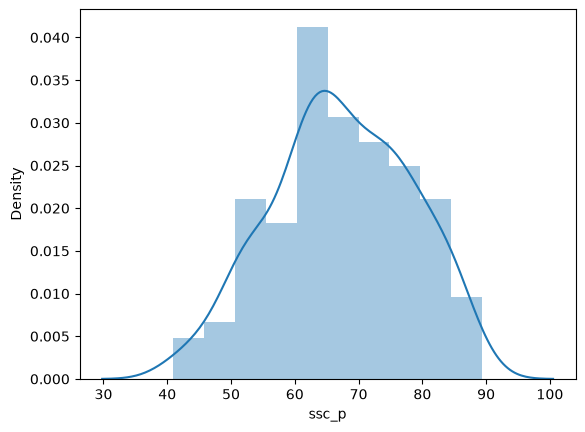

In [4]:
import seaborn as sns
sns.distplot(dataset["ssc_p"])

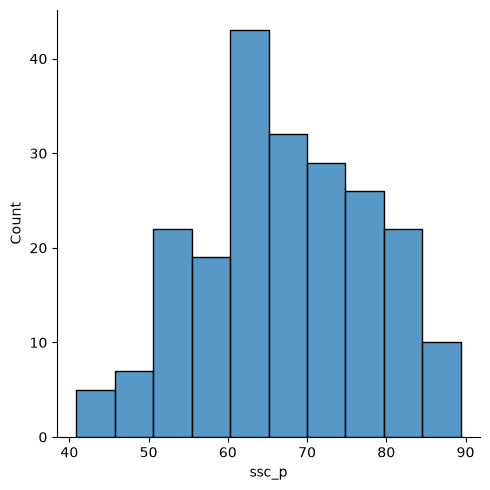

In [6]:
import seaborn as sns
sns.displot(dataset["ssc_p"])

<Axes: xlabel='ssc_p', ylabel='Count'>

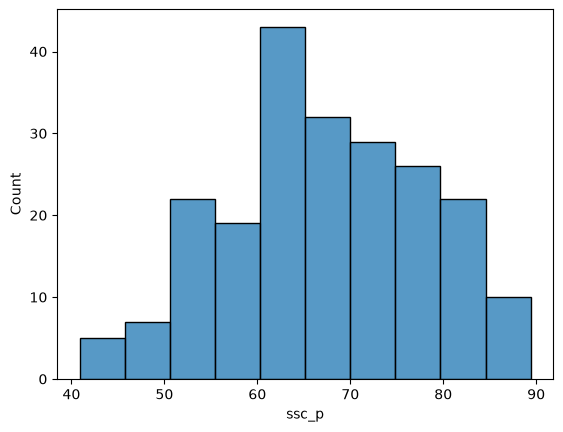

In [7]:
sns.histplot(dataset["ssc_p"])

In [24]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    sample=dataset
    sample_mean=sample.mean()
    sample_std=sample.std()
    print('Mean=%.3f,std=%.3f' %(sample_mean,sample_std))
    dist=norm(sample_mean,sample_std)   #to define the normal distribution using meand standard deviation
    print("Dist",dist)
    values=[value for value in range(startrange,endrange)]
    print("value",values)
    probabilities=[dist.pdf(value) for value in values]
    print("probabilities",probabilities)
    prob=sum(probabilities)
    print("sum(probabilities)",prob)
    print('The area between range({},{}):{}'.format(startrange,endrange,prob))
    
    
    
 

C:\Users\Sangeetha Viji\AppData\Local\Temp\ipykernel_25016\718881112.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax=sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=67.303,std=10.827
Dist <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000018A45913250>
value [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
probabilities [np.float64(0.0015329114224828535), np.float64(0.0019267051556190002), np.float64(0.002401091837106753), np.float64(0.002966863705543068), np.float64(0.003634810156509462), np.float64(0.004415309815023451), np.float64(0.005317848311682825), np.float64(0.006350472216915636), np.float64(0.0075191960450905265), np.float64(0.008827385817478143)]
sum(probabilities) 0.04489259448345172
The area between range(40,50):0.04489259448345172


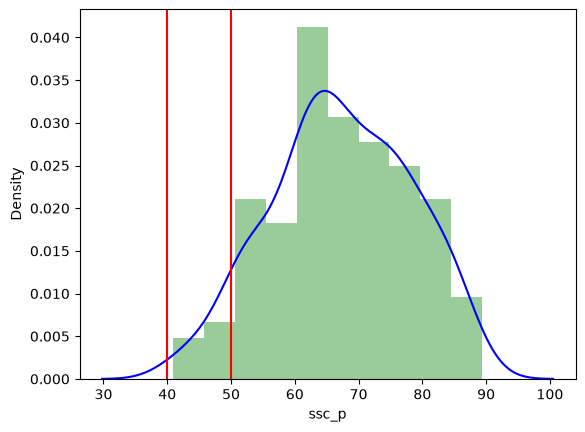

In [25]:
get_pdf_probability(dataset["ssc_p"],40,50)

In [31]:
#!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 22.0 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 23.5 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 21.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [wrapt]
   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ---------------- ----------------------- 2/5 [interface-meta]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formul

In [34]:
#CDF

from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset['ssc_p'])
ecdf(60)

np.float64(0.24186046511627907)

In [45]:
#StandardNormalDistribution

def stdNBgraph(dataset):
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j-mean)/std) for j in values]
    sns.distplot(z_score,kde=True)
    

C:\Users\Sangeetha Viji\AppData\Local\Temp\ipykernel_25016\267784661.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


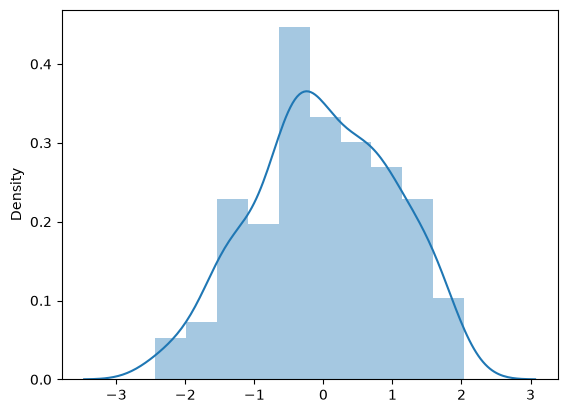

In [46]:
stdNBgraph(dataset['ssc_p'])